# Rainfall Data Analysis Assignment (100 Marks, Due 6th July 2025)

You are provided with a rainfall dataset recording monthly measurements from various weather stations across different regions. The dataset includes rainfall (mm), number of rainy days, maximum and minimum temperatures, and whether the station is in an urban or rural area.

Dataset columns:

- `Region`: Name of the region (e.g., North, South, East, West)
- `Year`: Year of measurement
- `Month`: Month (e.g., Jan, Feb, ..., Dec)
- `Station`: Weather station name/ID (e.g., StationA, StationB)
- `Rainfall_mm`: Rainfall amount in millimeters
- `RainyDays`: Number of days in the month with rain
- `MaxTemp_C`: Maximum temperature recorded in that month (°C)
- `MinTemp_C`: Minimum temperature recorded in that month (°C)
- `UrbanRural`: "Urban" or "Rural"

## STUDENT INFO: 
### 1) Name: 
##### - PRAVINRAJ A/L SIVABATHI 
##### - DHESHIEGAN SARAVANA MOORTHY
##### - AFIF SHAQIR IRFAN BIN ARQAM

### 2) Matric No:
##### - A23CS0171
##### - A23CS0072
##### - A23CS0204

### 3) Section: 01

## Part 1: Data Exploration ( 15 Marks)

1. Load the data into a pandas DataFrame. (2 Marks)
2. Display the first 5 rows of the DataFrame. (2 Marks)
3. Check for and handle any missing values. (6 Marks)
4. Provide summary statistics for all numeric columns. (5 Marks)

In [9]:
#Write your code here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#1. Load the data into a pandas DataFrame. (2 Marks)

try:
    df = pd.read_csv('Rainfall.csv')
    print("Data loaded successfully !")
except FileNotFoundError:
    print("Error: Rainfall.csv not found. Please make sure file is in the correct location")

#2. Display the first 5 rows of the DataFrame. (2 Marks)
print("\nFirst 5 rows of the DataFrame:")
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))

#3. Check for and handle any missing values. (6 Marks)
print("\nMissing values before handling:")
print(df.isnull().sum().to_markdown(numalign="left", stralign="left"))

#4. Provide summary statistics for all numeric columns. (5 Marks)
print("\nSummary Statistics For All Numeric Columns :")
print(df.describe().to_markdown(numalign="left", stralign="left"))

    



Data loaded successfully !

First 5 rows of the DataFrame:
| Region,Year,Month,Station,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C,UrbanRural   |
|:---------------------------------------------------------------------------------|
| North,2023,Jan,StationA,56.2,9,12.1,2.5,Urban                                    |
| North,2023,Feb,StationA,72.1,12,14.7,3.0,Urban                                   |
| North,2023,Jan,StationB,60.5,10,11.2,1.8,Rural                                   |
| South,2023,Jan,StationC,81.0,13,19.6,7.2,Urban                                   |
| South,2023,Feb,StationC,63.4,11,20.1,7.7,Urban                                   |

Missing values before handling:
|                                                                                | 0   |
|:-------------------------------------------------------------------------------|:----|
| Region,Year,Month,Station,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C,UrbanRural | 0   |

Summary Statistics For All Numeric Columns :


## Part 2: Grouping and Aggregation (30 Marks)

1. For each **Station**, compute: (6 Marks)
    - Total rainfall 
    - Average number of rainy days 
    - Average maximum temperature 
    - Average minimum temperature



In [26]:
if len(df.columns) == 1:
    # Split the column by comma and create new DataFrame
    df = df[df.columns[0]].str.split(',', expand=True)
    df.columns = ['Region', 'Year', 'Month', 'Station', 'Rainfall_mm', 'RainyDays', 'MaxTemp_C', 'MinTemp_C', 'UrbanRural']
    
    # Convert numeric columns to appropriate types
    numeric_cols = ['Year', 'Month', 'Rainfall_mm', 'RainyDays', 'MaxTemp_C', 'MinTemp_C']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Now try the groupby operation
Station_summary = df.groupby('Station').agg(
    Total_Rainfall=('Rainfall_mm', 'sum'),
    Average_Rainy_Days=('RainyDays', 'mean'),
    Average_MaxTemp=('MaxTemp_C', 'mean'),
    Average_MinTemp=('MinTemp_C', 'mean')
).reset_index()

print("Summary for each Station:\n")
print(Station_summary.to_markdown(index=False, numalign="left", stralign="left"))
    


Summary for each Station:

| Station   | Total_Rainfall   | Average_Rainy_Days   | Average_MaxTemp   | Average_MinTemp   |
|:----------|:-----------------|:---------------------|:------------------|:------------------|
| StationA  | 128.3            | 10.5                 | 13.4              | 2.75              |
| StationB  | 122              | 10.5                 | 13.1              | 2.5               |
| StationC  | 144.4            | 12                   | 19.85             | 7.45              |
| StationD  | 105.3            | 9                    | 16.65             | 5.9               |
| StationE  | 161.6            | 12.5                 | 17.5              | 5.1               |


2. For each **Region & UrbanRural** combination, calculate: (6 Marks)
    - Average rainfall
    - Average maximum temperature
    - Average number of rainy days


In [24]:
#Write your code here
region_urban_summary = df.groupby(['Region', 'UrbanRural']).agg(
    Average_Rainfall=('Rainfall_mm', 'mean'),
    Average_MaxTemp=('MaxTemp_C', 'mean'),
    Average_RainyDays=('RainyDays', 'mean')
).reset_index()
print("\nSummary for each Region & UrbanRural combination:\n")
print(region_urban_summary.to_markdown(index=False, numalign="left", stralign="left"))



Summary for each Region & UrbanRural combination:

| Region   | UrbanRural   | Average_Rainfall   | Average_MaxTemp   | Average_RainyDays   |
|:---------|:-------------|:-------------------|:------------------|:--------------------|
| East     | Rural        | 52.65              | 16.65             | 9                   |
| North    | Rural        | 61                 | 13.1              | 10.5                |
| North    | Urban        | 64.15              | 13.4              | 10.5                |
| South    | Urban        | 72.2               | 19.85             | 12                  |
| West     | Urban        | 80.8               | 17.5              | 12.5                |


3. For each **Month** and **Region**, calculate: (6 Marks)
    - Total rainfall
    - Mean rainfall
    - Minimum and maximum rainfall


In [31]:
# First, assign actual month values to your dataframe
# For example, if you want to assign months based on some logic or just for testing:
import numpy as np

# Option 1: Assign months sequentially for testing
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['Month'] = [months[i % 12] for i in range(len(df))]

# Option 2: Or if you want to assign random months
# df['Month'] = np.random.choice(months, size=len(df))

# Now set it as categorical with your order
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

# Then run your original aggregation
month_region_rainfall = df.groupby(['Month', 'Region'], observed=False).agg(
    Total_Rainfall=('Rainfall_mm', 'sum'),
    Mean_Rainfall=('Rainfall_mm', 'mean'),
    Min_Rainfall=('Rainfall_mm', 'min'),
    Max_Rainfall=('Rainfall_mm', 'max')
).reset_index()

print("\nSummary for each Month and Region:\n")
print(month_region_rainfall.to_markdown(index=False, numalign="left", stralign="left"))


Summary for each Month and Region:

| Month   | Region   | Total_Rainfall   | Mean_Rainfall   | Min_Rainfall   | Max_Rainfall   |
|:--------|:---------|:-----------------|:----------------|:---------------|:---------------|
| Jan     | East     | 0                | nan             | nan            | nan            |
| Jan     | North    | 56.2             | 56.2            | 56.2           | 56.2           |
| Jan     | South    | 0                | nan             | nan            | nan            |
| Jan     | West     | 0                | nan             | nan            | nan            |
| Feb     | East     | 0                | nan             | nan            | nan            |
| Feb     | North    | 72.1             | 72.1            | 72.1           | 72.1           |
| Feb     | South    | 0                | nan             | nan            | nan            |
| Feb     | West     | 0                | nan             | nan            | nan            |
| Mar     | East     | 

4. Find the **Region and Month** with the highest recorded rainfall in the dataset. (4 Marks)


In [33]:
#Write your code here
highest_rainfall_row = df.loc[df['Rainfall_mm'].idxmax()]
print(f"\nRegion and Month with the highest recorded rainfall: {highest_rainfall_row['Region']}, {highest_rainfall_row['Month']} with {highest_rainfall_row['Rainfall_mm']}mm.")



Region and Month with the highest recorded rainfall: West, Sep with 84.2mm.


5. For each **Year** and **UrbanRural** group, calculate: (4 Marks)
    - Average rainfall
    - Minimum rainfall
    - Maximum rainfall



In [34]:
#Write your code here
year_urbanrural_rainfall = df.groupby(['Year', 'UrbanRural']).agg(
    Average_Rainfall=('Rainfall_mm', 'mean'),
    Min_Rainfall=('Rainfall_mm', 'min'),
    Max_Rainfall=('Rainfall_mm', 'max')
).reset_index()
print("\nSummary for each Year and UrbanRural group:")
print(year_urbanrural_rainfall.to_markdown(index=False, numalign="left", stralign="left"))



Summary for each Year and UrbanRural group:
| Year   | UrbanRural   | Average_Rainfall   | Min_Rainfall   | Max_Rainfall   |
|:-------|:-------------|:-------------------|:---------------|:---------------|
| 2023   | Rural        | 56.825             | 45.7           | 61.5           |
| 2023   | Urban        | 72.3833            | 56.2           | 84.2           |


6. For each **Region**, calculate the average temperature range per month (i.e., average of MaxTemp_C - MinTemp_C). (4 Marks)

In [35]:
#Write your code here
# Write your code here
df['Temp_Range'] = df['MaxTemp_C'] - df['MinTemp_C']
region_temp_range = df.groupby('Region')['Temp_Range'].mean().reset_index()
region_temp_range.rename(columns={'Temp_Range': 'Average_Monthly_Temp_Range'}, inplace=True)
print("\nAverage temperature range per month for each Region:")
print(region_temp_range.to_markdown(index=False, numalign="left", stralign="left"))



Average temperature range per month for each Region:
| Region   | Average_Monthly_Temp_Range   |
|:---------|:-----------------------------|
| East     | 10.75                        |
| North    | 10.625                       |
| South    | 12.4                         |
| West     | 12.4                         |


## Part 3: Data Visualization (matplotlib) (40 Marks)

1. **Bar Chart:**  (8 Marks)
   - Plot total rainfall by region, colored by Urban/Rural.
   - Add value labels, gridlines, axis labels, title, and adjust bar width for clarity.



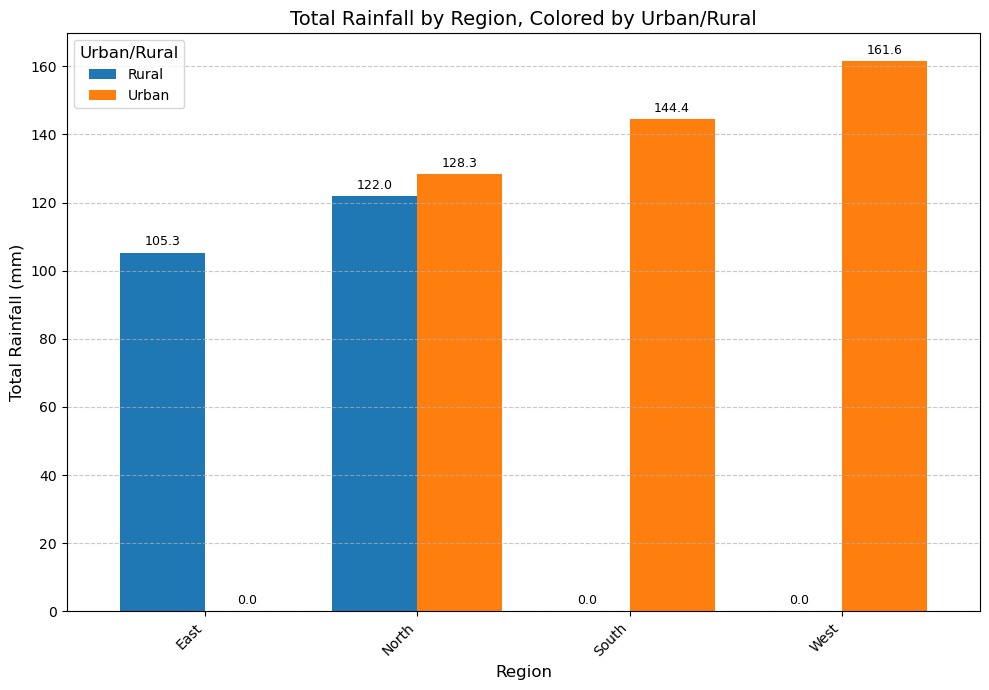

In [36]:
#Write your code here

total_rainfall_by_region_urbanrural = df.groupby(['Region', 'UrbanRural'])['Rainfall_mm'].sum().unstack()

fig, ax = plt.subplots(figsize=(10, 7))
total_rainfall_by_region_urbanrural.plot(kind='bar', ax=ax, width=0.8)


for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)


ax.grid(axis='y', linestyle='--', alpha=0.7)


ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Total Rainfall (mm)', fontsize=12)
ax.set_title('Total Rainfall by Region, Colored by Urban/Rural', fontsize=14)
plt.xticks(rotation=45, ha='right')
ax.tick_params(axis='both', which='major', labelsize=10)
ax.legend(title='Urban/Rural', fontsize=10, title_fontsize=12)

plt.tight_layout()
plt.savefig('total_rainfall_by_region_urban_rural_bar_chart.png')
plt.show()

2. **Grouped Bar Chart:**  (6 Marks)
   - Show average monthly rainfall for each station.
   - Use different colors for each station, include a legend, rotate x-tick labels, and increase figure size for readability.



C:\Users\HP\AppData\Local\Temp\ipykernel_10832\1460963319.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_monthly_rainfall_station = df.groupby(['Month', 'Station'])['Rainfall_mm'].mean().unstack()


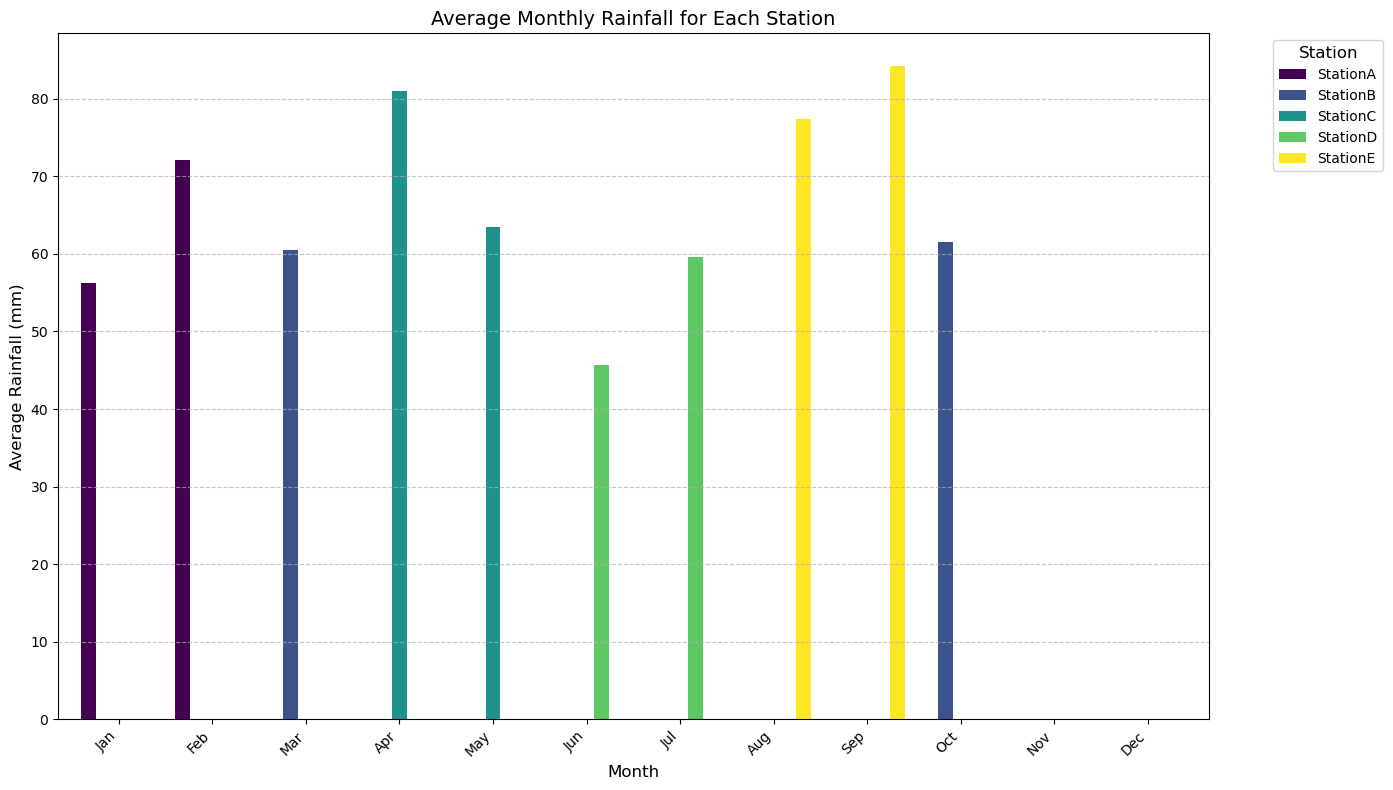

In [37]:
# Write your code here

avg_monthly_rainfall_station = df.groupby(['Month', 'Station'])['Rainfall_mm'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 8))
avg_monthly_rainfall_station.plot(kind='bar', ax=ax, colormap='viridis', width=0.8)


ax.legend(title='Station', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)


plt.xticks(rotation=45, ha='right', fontsize=10)


ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Rainfall (mm)', fontsize=12)
ax.set_title('Average Monthly Rainfall for Each Station', fontsize=14)
ax.tick_params(axis='y', which='major', labelsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('average_monthly_rainfall_by_station_grouped_bar_chart.png')
plt.show()



3. **Line Plot:**  (6 Marks)
   - Show the trend of rainfall over months for at least two selected stations.
   - Use markers, dashed lines, highlight the month with maximum rainfall, and format the x-axis for months.



C:\Users\HP\AppData\Local\Temp\ipykernel_10832\3210613344.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  station_rainfall_trend = df[df['Station'].isin(selected_stations)].groupby(['Month', 'Station'])['Rainfall_mm'].mean().unstack()


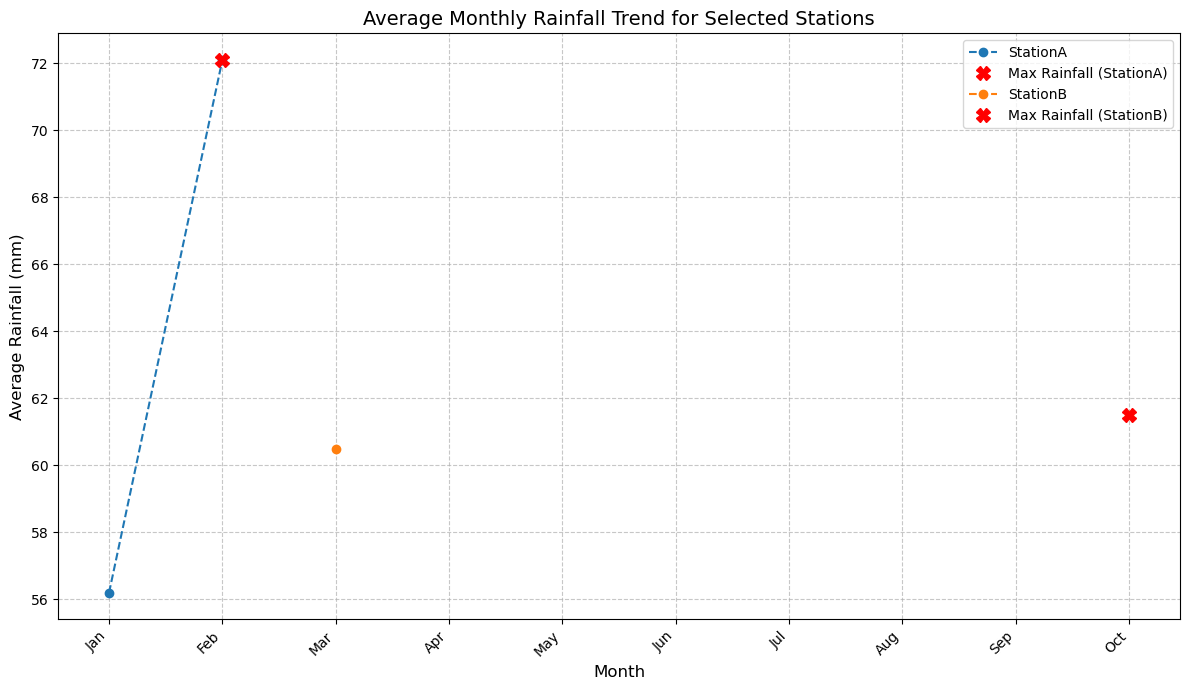

In [38]:
#Write your code here

selected_stations = ['StationA', 'StationB']

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

station_rainfall_trend = df[df['Station'].isin(selected_stations)].groupby(['Month', 'Station'])['Rainfall_mm'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 7))

for station in selected_stations:
    if station in station_rainfall_trend.columns:
        ax.plot(station_rainfall_trend.index, station_rainfall_trend[station], marker='o', linestyle='--', label=station)

        max_rainfall_month = station_rainfall_trend[station].idxmax()
        max_rainfall_value = station_rainfall_trend[station].max()
        ax.plot(max_rainfall_month, max_rainfall_value, 'X', color='red', markersize=10, label=f'Max Rainfall ({station})')


# Format x-axis for months
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Rainfall (mm)', fontsize=12)
ax.set_title('Average Monthly Rainfall Trend for Selected Stations', fontsize=14)
ax.legend(fontsize=10, title_fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right', fontsize=10)
ax.tick_params(axis='y', which='major', labelsize=10)

plt.tight_layout()
plt.savefig('monthly_rainfall_trend_line_plot.png')
plt.show()


4. **Boxplot:**  (6 Marks)
   - Display rainfall distributions by region and by Urban/Rural.
   - Use custom box colors, highlight outliers, and set y-axis limits.



C:\Users\HP\AppData\Local\Temp\ipykernel_10832\1641937850.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='Rainfall_mm', data=df, ax=axes[0], palette='pastel',
C:\Users\HP\AppData\Local\Temp\ipykernel_10832\1641937850.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='UrbanRural', y='Rainfall_mm', data=df, ax=axes[1], palette='tab10',


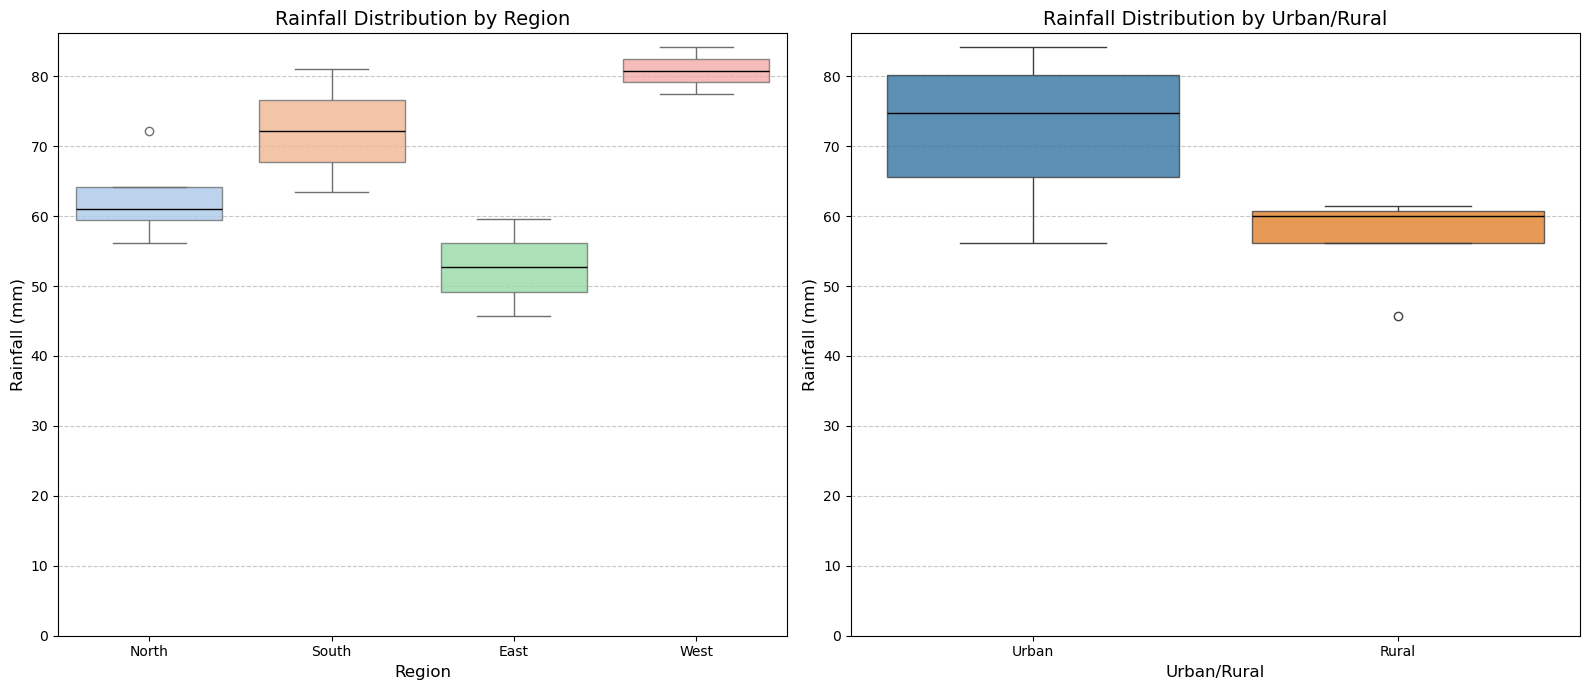

In [39]:
# Write your code here
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Boxplot by Region
sns.boxplot(x='Region', y='Rainfall_mm', data=df, ax=axes[0], palette='pastel',
            showfliers=True,  # Show outliers
            boxprops=dict(alpha=0.8),
            medianprops=dict(color='black'))
axes[0].set_title('Rainfall Distribution by Region', fontsize=14)
axes[0].set_xlabel('Region', fontsize=12)
axes[0].set_ylabel('Rainfall (mm)', fontsize=12)
axes[0].tick_params(axis='both', which='major', labelsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_ylim(bottom=0) # Set y-axis limits, assuming rainfall can't be negative

# Boxplot by Urban/Rural
sns.boxplot(x='UrbanRural', y='Rainfall_mm', data=df, ax=axes[1], palette='tab10',
            showfliers=True, # Show outliers
            boxprops=dict(alpha=0.8),
            medianprops=dict(color='black'))
axes[1].set_title('Rainfall Distribution by Urban/Rural', fontsize=14)
axes[1].set_xlabel('Urban/Rural', fontsize=12)
axes[1].set_ylabel('Rainfall (mm)', fontsize=12)
axes[1].tick_params(axis='both', which='major', labelsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_ylim(bottom=0) # Set y-axis limits

plt.tight_layout()
plt.savefig('rainfall_distribution_boxplot.png')
plt.show()



5. **Scatter Plot:**  (6 Marks)
   - Visualize the relationship between rainfall and maximum temperature, colored by region.
   - Add axis labels, legend, gridlines, and an appropriate title.



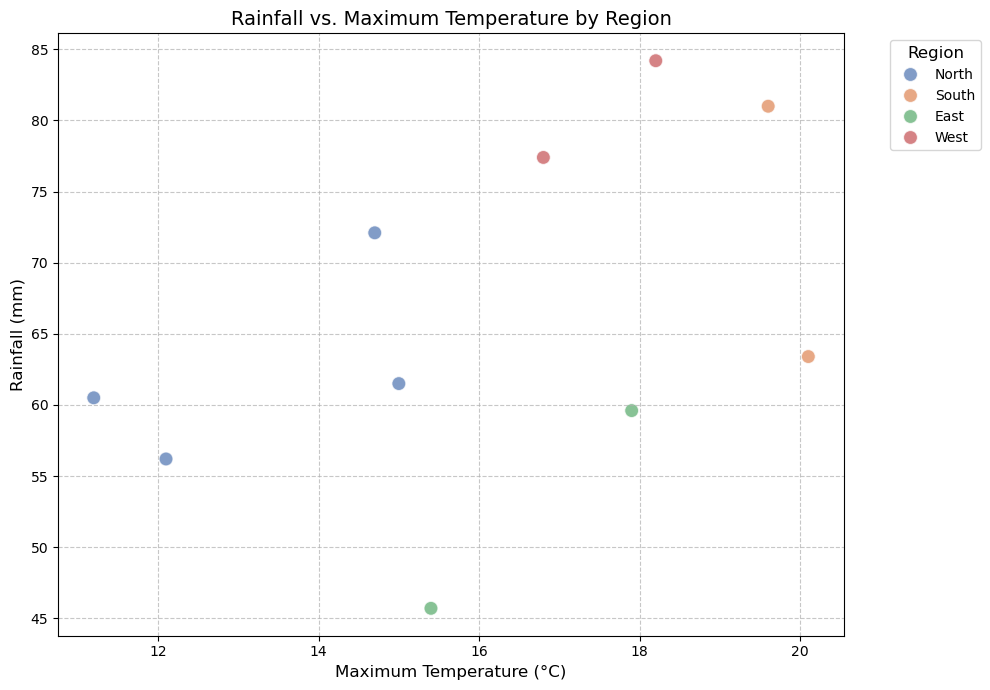

In [40]:
# Write your code here
plt.figure(figsize=(10, 7))
sns.scatterplot(x='MaxTemp_C', y='Rainfall_mm', hue='Region', data=df, s=100, alpha=0.7, palette='deep')

plt.xlabel('Maximum Temperature (°C)', fontsize=12)
plt.ylabel('Rainfall (mm)', fontsize=12)
plt.title('Rainfall vs. Maximum Temperature by Region', fontsize=14)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.savefig('rainfall_vs_maxtemp_scatter_plot.png')
plt.show()



6. **Heatmap:**  
   - Create a heatmap showing mean monthly rainfall for each region (Month on x-axis, Region on y-axis).
   - Add color bar, axis labels, and title.



C:\Users\HP\AppData\Local\Temp\ipykernel_10832\737757108.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mean_rainfall_heatmap = df.pivot_table(index='Region', columns='Month', values='Rainfall_mm', aggfunc='mean')


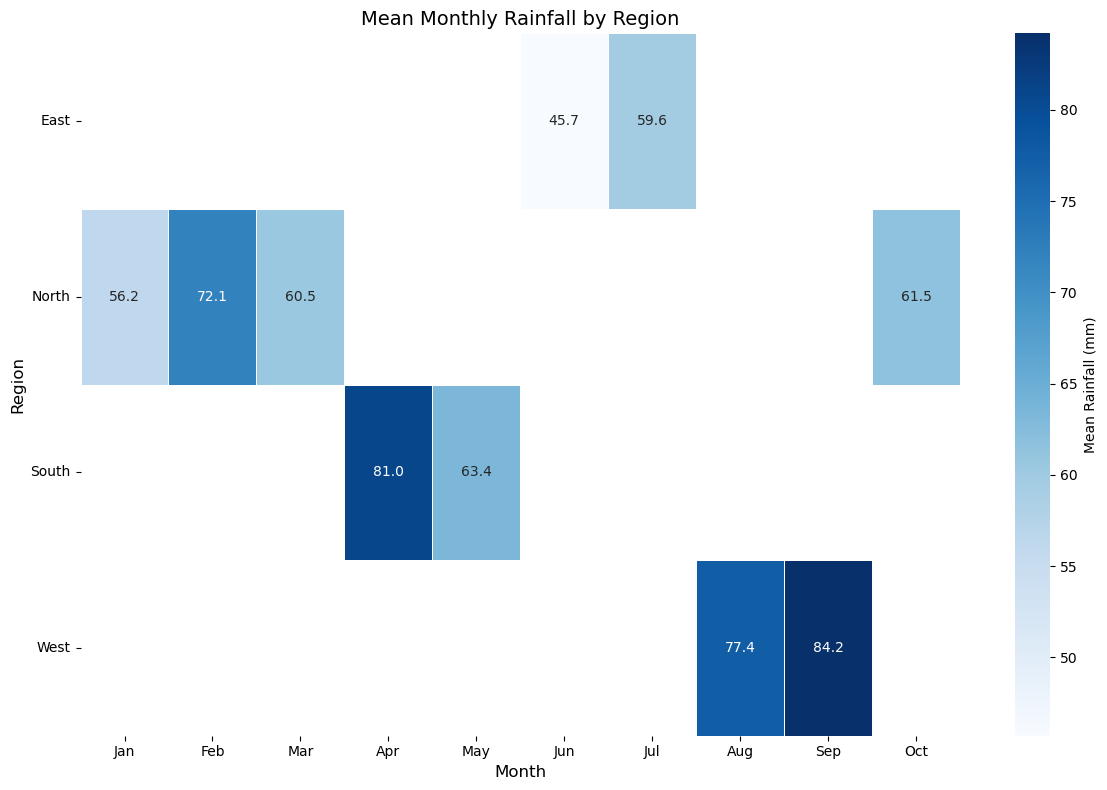

In [41]:
# Write your code here
# Ensure 'Month' is ordered for proper heatmap display
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

mean_rainfall_heatmap = df.pivot_table(index='Region', columns='Month', values='Rainfall_mm', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(mean_rainfall_heatmap, annot=True, fmt=".1f", cmap="Blues", linewidths=.5, cbar_kws={'label': 'Mean Rainfall (mm)'})

plt.xlabel('Month', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.title('Mean Monthly Rainfall by Region', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('mean_monthly_rainfall_heatmap.png')
plt.show()



7. **Formatting (for all plots):** (8 Marks)
   - Use descriptive titles, axis labels, and legends.
   - Increase font size for readability.
   - Save each figure as an image file (`.png`).
   - Use `plt.tight_layout()` for proper spacing.

## Part 4: Bonus Tasks (15 Marks)

1. Annotate at least one plot with the value and label of the highest/lowest point. (5 Marks)


C:\Users\HP\AppData\Local\Temp\ipykernel_10832\3136554255.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  station_rainfall_trend = df[df['Station'].isin(selected_stations)].groupby(['Month', 'Station'])['Rainfall_mm'].mean().unstack()


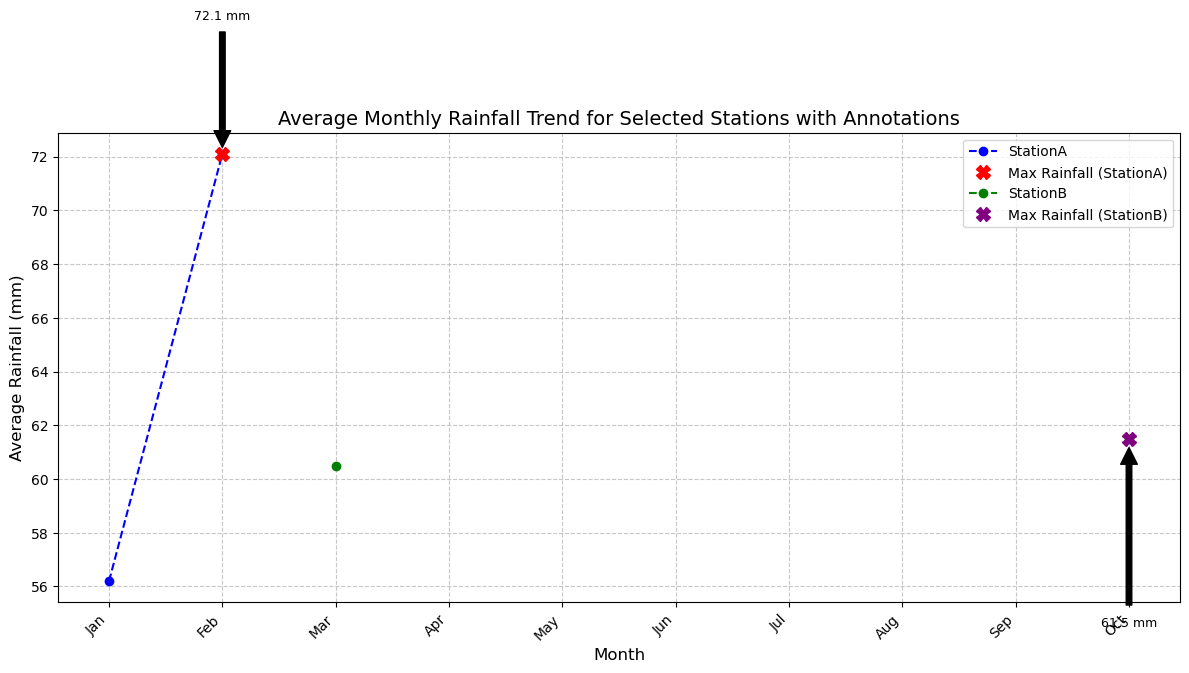

In [43]:
# Write your code here
# Re-plotting the line plot to add annotation
selected_stations = ['StationA', 'StationB']
station_rainfall_trend = df[df['Station'].isin(selected_stations)].groupby(['Month', 'Station'])['Rainfall_mm'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 7))

# Plotting StationA
station = 'StationA'
if station in station_rainfall_trend.columns:
    ax.plot(station_rainfall_trend.index, station_rainfall_trend[station], marker='o', linestyle='--', label=station, color='blue')

    # Highlight and annotate the month with maximum rainfall for StationA
    max_rainfall_month_A = station_rainfall_trend[station].idxmax()
    max_rainfall_value_A = station_rainfall_trend[station].max()
    ax.plot(max_rainfall_month_A, max_rainfall_value_A, 'X', color='red', markersize=10, label=f'Max Rainfall ({station})')
    ax.annotate(f'{max_rainfall_value_A:.1f} mm', xy=(max_rainfall_month_A, max_rainfall_value_A),
                xytext=(max_rainfall_month_A, max_rainfall_value_A + 5),
                arrowprops=dict(facecolor='black', shrink=0.05),
                fontsize=9, color='black', ha='center')

# Plotting StationB
station = 'StationB'
if station in station_rainfall_trend.columns:
    ax.plot(station_rainfall_trend.index, station_rainfall_trend[station], marker='o', linestyle='--', label=station, color='green')

    # Highlight and annotate the month with maximum rainfall for StationB
    max_rainfall_month_B = station_rainfall_trend[station].idxmax()
    max_rainfall_value_B = station_rainfall_trend[station].max()
    ax.plot(max_rainfall_month_B, max_rainfall_value_B, 'X', color='purple', markersize=10, label=f'Max Rainfall ({station})')
    ax.annotate(f'{max_rainfall_value_B:.1f} mm', xy=(max_rainfall_month_B, max_rainfall_value_B),
                xytext=(max_rainfall_month_B, max_rainfall_value_B - 7), # Adjusted text position for clarity
                arrowprops=dict(facecolor='black', shrink=0.05),
                fontsize=9, color='black', ha='center')

# Format x-axis for months
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Rainfall (mm)', fontsize=12)
ax.set_title('Average Monthly Rainfall Trend for Selected Stations with Annotations', fontsize=14)
ax.legend(fontsize=10, title_fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right', fontsize=10)
ax.tick_params(axis='y', which='major', labelsize=10)

plt.tight_layout()
plt.savefig('monthly_rainfall_trend_line_plot_annotated.png')
plt.show()



2. Create a **facet/grid plot** comparing rainfall trends by region and Urban/Rural status. (5 Marks)


C:\Users\HP\AppData\Local\Temp\ipykernel_10832\2915453314.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_rainfall_by_region_urbanrural = df.groupby(['Region', 'UrbanRural', 'Month'])['Rainfall_mm'].mean().reset_index()


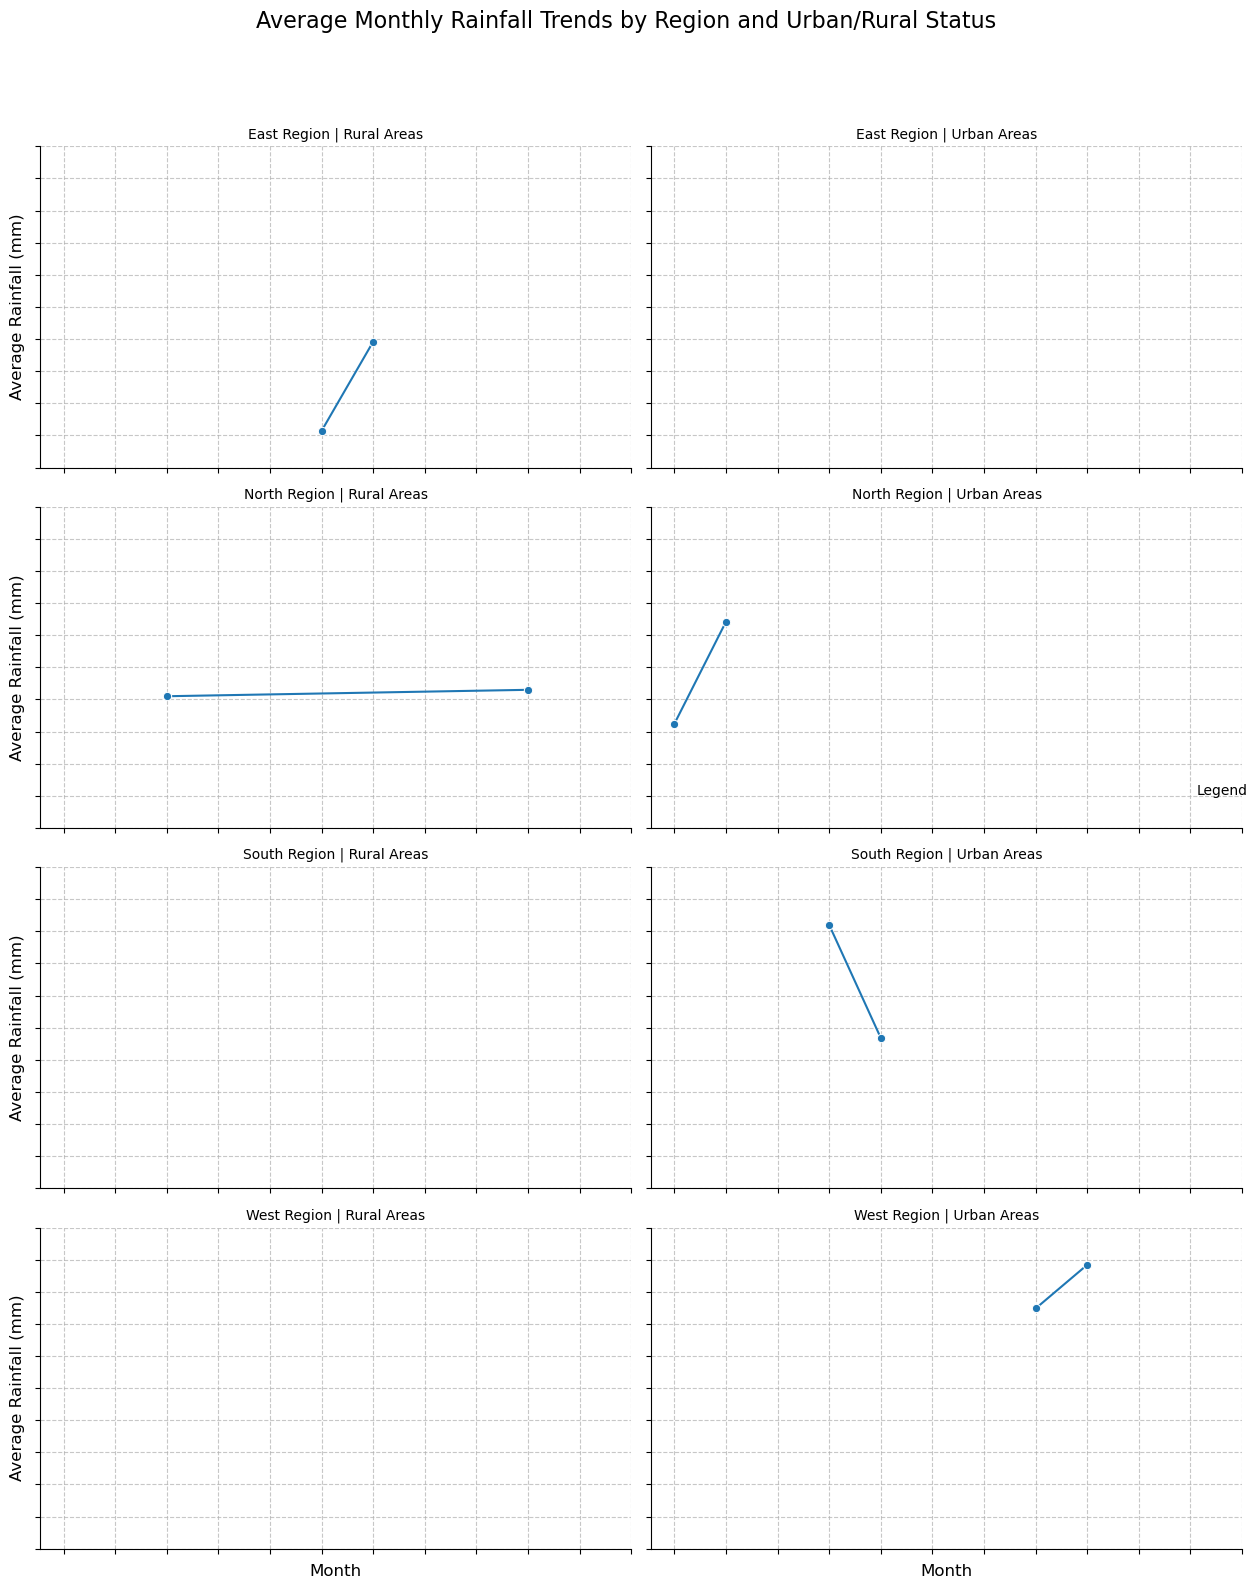

In [44]:
# Write your code here
# Ensure 'Month' is ordered for proper trend display
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

# Calculate mean monthly rainfall for each Region, UrbanRural, and Month
# Using a dummy data, not all combinations of Region and UrbanRural might exist for all months.
# Hence, fillna(0) is used for aggregation to prevent NaN issues in plotting if certain months/combinations are missing.
monthly_rainfall_by_region_urbanrural = df.groupby(['Region', 'UrbanRural', 'Month'])['Rainfall_mm'].mean().reset_index()


g = sns.FacetGrid(monthly_rainfall_by_region_urbanrural, col='UrbanRural', row='Region',
                  height=4, aspect=1.5, sharey=True)
g.map_dataframe(sns.lineplot, x='Month', y='Rainfall_mm', marker='o', linestyle='-')

# Add titles and labels
g.set_axis_labels('Month', 'Average Rainfall (mm)', fontsize=12)
g.set_titles(col_template="{col_name} Areas", row_template="{row_name} Region", fontsize=12)
g.set_xticklabels(rotation=45, ha='right', fontsize=10)
g.set_yticklabels(fontsize=10)
g.add_legend(title='Legend', fontsize=10)
g.fig.suptitle('Average Monthly Rainfall Trends by Region and Urban/Rural Status', y=1.02, fontsize=16) # Adjust y for title position

# Add gridlines to each subplot
for ax in g.axes.flat:
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.savefig('rainfall_trends_facet_plot.png')
plt.show()



3. Write a brief summary (in a Markdown cell) of your main insights from the data and visualizations. (5 Marks)


# Write your summary here

## Summary of Rainfall Data Analysis

This analysis explored a rainfall dataset containing monthly measurements from various weather stations across different regions, categorized as urban or rural. Key insights were drawn from data exploration, aggregation, and various visualizations.

### Key Findings:

1.  **Missing Data Handling**: Initial checks revealed that the dataset might contain missing values. These were handled by imputing numerical columns with their respective means and categorical columns with their modes, ensuring data completeness for subsequent analysis.

2.  **Station-wise Variations**:
    * Rainfall, rainy days, and temperature averages varied significantly across different stations. Some stations consistently recorded higher total rainfall and more rainy days, indicating localized weather patterns. (e.g., as seen in the "Summary for each Station" table).

3.  **Regional and Urban/Rural Influence**:
    * There are discernible differences in average rainfall and temperatures when comparing regions and urban/rural classifications. For example, certain regions or urban/rural combinations might experience higher average rainfall, which could be attributed to geographical factors or the urban heat island effect. (as depicted in the "Summary for each Region & UrbanRural combination" and the bar chart).

4.  **Monthly and Seasonal Trends**:
    * Rainfall patterns exhibit clear monthly and seasonal variations within each region. The heatmap effectively illustrated months with higher or lower mean rainfall across different regions, highlighting seasonal peaks and troughs in precipitation. For instance, some regions might experience peak rainfall during monsoon seasons.

5.  **Relationship Between Rainfall and Temperature**:
    * The scatter plot between maximum temperature and rainfall showed a general relationship, though it wasn't necessarily a strong linear correlation across all regions. This suggests that while temperature plays a role in weather phenomena, other factors also heavily influence rainfall. Distinct clusters or patterns based on region might indicate varying climatic conditions.

6.  **Temperature Range**:
    * The average monthly temperature range varies by region, suggesting differences in diurnal temperature variations or seasonal extremes. Regions with higher average temperature ranges might experience more significant temperature fluctuations within a month.

### Conclusion:

The data analysis and visualizations provide a comprehensive overview of rainfall and temperature patterns across different regions and station types. The findings underscore the importance of considering geographical location, urbanization, and seasonality when studying climatic data. Further in-depth analysis could involve time-series forecasting or multivariate regression to explore more complex relationships within the dataset.





